<a href="https://colab.research.google.com/github/Shehriyarrkhann/AI-LABS/blob/main/AI_Cyber_Attack_Path_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Cyber Attack Path Simulator

## Mid-Term AI Project

### Developed By:
- Your Name
- Group Member Name

### Technologies Used:
- Python
- NetworkX
- Matplotlib
- Google Colab

# Install libraries

In [23]:
!pip install networkx matplotlib pandas

# Import Libraries

In [25]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import time

from collections import deque
from queue import PriorityQueue

# Network Topology

The graph represents a simulated computer network where:
- Nodes represent systems
- Edges represent communication paths
- Weights represent attack costs/risk

In [26]:
graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'A': 2, 'D': 3, 'F': 5},
    'C': {'A': 4, 'D': 2, 'H': 6},
    'D': {'B': 3, 'C': 2, 'E': 2},
    'E': {'D': 2, 'G': 3, 'H': 5},
    'F': {'B': 5, 'G': 4},
    'G': {'F': 4, 'E': 3},
    'H': {'C': 6, 'E': 5}
}

start = 'A'
goal = 'E'

# Problem Formulation

In this project, the computer network is modeled as a weighted graph where:

Nodes represent systems such as workstations, servers, and databases
Edges represent communication links between systems
Weights represent attack cost, risk level, or effort required to move between systems

The attacker starts from a defined entry node (Start Node) and aims to reach a high-value target system (Goal Node).

The objective is to analyze different AI search algorithms to determine the most efficient attack path based on cost, steps, and exploration efficiency.

# Network Visualization

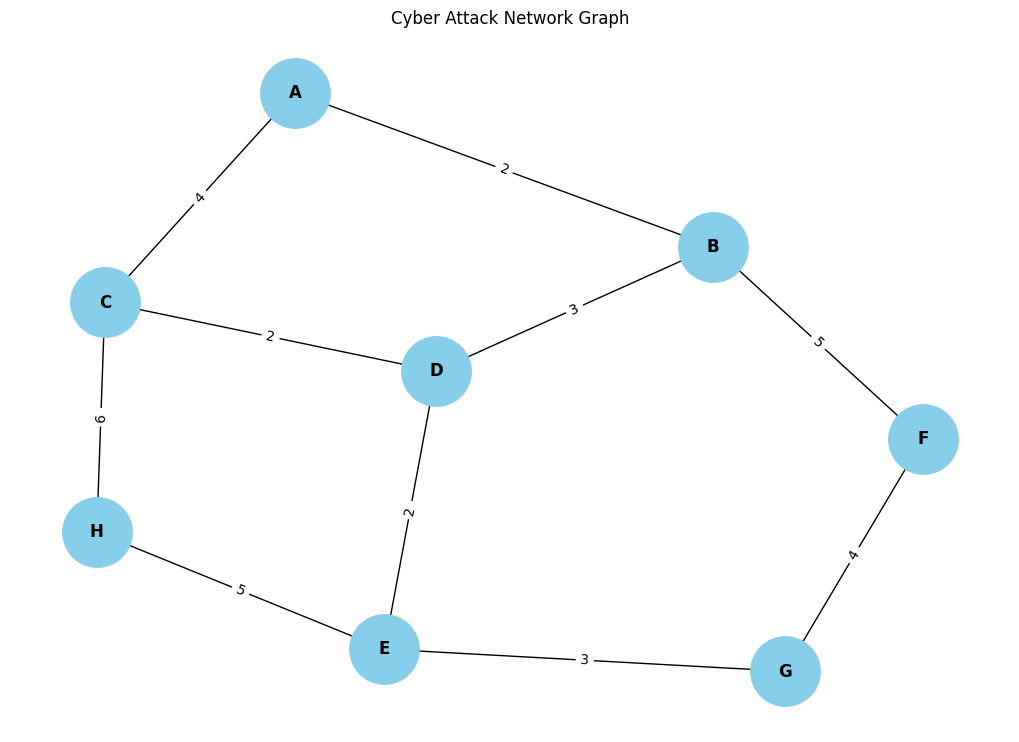

In [27]:
G = nx.Graph()

for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10,7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=2500,
    font_size=12,
    font_weight='bold'
)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Cyber Attack Network Graph")
plt.show()

# Breadth First Search (BFS)

BFS explores the graph level-by-level and finds the shortest path in terms of number of steps.

In [28]:
def bfs(graph, start, goal):

    start_time = time.time()

    queue = deque([(start, [start])])

    visited = set()

    nodes_expanded = 0

    while queue:

        current, path = queue.popleft()

        if current == goal:

            end_time = time.time()

            return {
                "Algorithm": "BFS",
                "Path": path,
                "Cost": len(path)-1,
                "Nodes Expanded": nodes_expanded,
                "Execution Time": (end_time-start_time)*1000
            }

        if current not in visited:

            visited.add(current)

            nodes_expanded += 1

            for neighbor in graph[current]:
                queue.append((neighbor, path+[neighbor]))

In [29]:
bfs_result = bfs(graph, start, goal)

print(bfs_result)

{'Algorithm': 'BFS', 'Path': ['A', 'B', 'D', 'E'], 'Cost': 3, 'Nodes Expanded': 6, 'Execution Time': 0.026702880859375}


# **DFS ALGORITHM**

In [30]:
def dfs(graph, start, goal):

    start_time = time.time()

    stack = [(start, [start])]

    visited = set()

    nodes_expanded = 0

    while stack:

        current, path = stack.pop()

        if current == goal:

            end_time = time.time()

            return {
                "Algorithm": "DFS",
                "Path": path,
                "Cost": len(path)-1,
                "Nodes Expanded": nodes_expanded,
                "Execution Time": (end_time-start_time)*1000
            }

        if current not in visited:

            visited.add(current)

            nodes_expanded += 1

            for neighbor in graph[current]:
                stack.append((neighbor, path+[neighbor]))

In [31]:
dfs_result = dfs(graph, start, goal)

print(dfs_result)

{'Algorithm': 'DFS', 'Path': ['A', 'C', 'H', 'E'], 'Cost': 3, 'Nodes Expanded': 3, 'Execution Time': 0.01621246337890625}


# Uniform Cost Search (UCS)

UCS finds the least-cost attack path.

In [32]:
def ucs(graph, start, goal):

    start_time = time.time()

    pq = PriorityQueue()

    pq.put((0, start, [start]))

    visited = set()

    nodes_expanded = 0

    while not pq.empty():

        cost, current, path = pq.get()

        if current == goal:

            end_time = time.time()

            return {
                "Algorithm": "UCS",
                "Path": path,
                "Cost": cost,
                "Nodes Expanded": nodes_expanded,
                "Execution Time": (end_time-start_time)*1000
            }

        if current not in visited:

            visited.add(current)

            nodes_expanded += 1

            for neighbor in graph[current]:

                new_cost = cost + graph[current][neighbor]

                pq.put((new_cost, neighbor, path+[neighbor]))

In [33]:
ucs_result = ucs(graph, start, goal)

print(ucs_result)

{'Algorithm': 'UCS', 'Path': ['A', 'B', 'D', 'E'], 'Cost': 7, 'Nodes Expanded': 4, 'Execution Time': 0.08082389831542969}


# A* Search Algorithm

A* uses heuristics to efficiently find the optimal attack path.

In [34]:
heuristic = {
    'A': 7,
    'B': 5,
    'C': 4,
    'D': 2,
    'E': 0,
    'F': 6,
    'G': 3,
    'H': 4
}

In [35]:
def astar(graph, start, goal):

    start_time = time.time()

    pq = PriorityQueue()

    pq.put((0, 0, start, [start]))

    visited = set()

    nodes_expanded = 0

    while not pq.empty():

        f_cost, g_cost, current, path = pq.get()

        if current == goal:

            end_time = time.time()

            return {
                "Algorithm": "A*",
                "Path": path,
                "Cost": g_cost,
                "Nodes Expanded": nodes_expanded,
                "Execution Time": (end_time-start_time)*1000
            }

        if current not in visited:

            visited.add(current)

            nodes_expanded += 1

            for neighbor in graph[current]:

                new_g = g_cost + graph[current][neighbor]

                new_f = new_g + heuristic[neighbor]

                pq.put((new_f, new_g, neighbor, path+[neighbor]))

In [36]:
astar_result = astar(graph, start, goal)

print(astar_result)

{'Algorithm': 'A*', 'Path': ['A', 'B', 'D', 'E'], 'Cost': 7, 'Nodes Expanded': 3, 'Execution Time': 0.064849853515625}


# Heuristic Design Explanation

The heuristic function h(n) estimates the cost from a node to the goal node.

In this project, heuristic values are assigned based on:

Estimated proximity to the goal node
Network risk level
Expected traversal difficulty

A* search uses:
f(n) = g(n) + h(n)

Where:

g(n) = actual cost from start
h(n) = estimated cost to goal

This helps A* find an optimal path efficiently compared to uninformed search methods.

# Hill Climbing

Hill Climbing chooses the locally best node using heuristic values.

In [37]:
def hill_climbing(graph, start, goal):

    start_time = time.time()

    current = start

    path = [current]

    total_cost = 0

    visited = set()

    while current != goal:

        visited.add(current)

        neighbors = graph[current]

        next_node = None

        best_h = float('inf')

        for neighbor in neighbors:

            if neighbor not in visited:

                if heuristic[neighbor] < best_h:

                    best_h = heuristic[neighbor]

                    next_node = neighbor

        if next_node is None:
            break

        total_cost += graph[current][next_node]

        current = next_node

        path.append(current)

    end_time = time.time()

    return {
        "Algorithm": "Hill Climbing",
        "Path": path,
        "Cost": total_cost,
        "Nodes Expanded": len(visited),
        "Execution Time": (end_time-start_time)*1000
    }

In [38]:
hill_result = hill_climbing(graph, start, goal)

print(hill_result)

{'Algorithm': 'Hill Climbing', 'Path': ['A', 'C', 'D', 'E'], 'Cost': 8, 'Nodes Expanded': 3, 'Execution Time': 0.012636184692382812}


# Hill Climbing Limitation (Local Maxima Problem)

Hill Climbing selects the best local option at each step without considering global optimal paths.

This can lead to a situation called a local maximum, where:

The algorithm reaches a node with no better neighboring nodes
It stops even though a better path exists elsewhere

This demonstrates that Hill Climbing is not always optimal in complex networks.

# Adversarial Search Model (Minimax)

This project models cybersecurity as a two-player game:

Attacker (Maximizer): tries to reach the target node
Defender (Minimizer): tries to block or increase attack cost

Minimax algorithm evaluates all possible moves and selects the optimal strategy assuming both players act optimally.

# Minimax Algorithm

The attacker tries to maximize success while the defender minimizes attack success.

In [39]:
tree = {
    'A': ['B', 'C'],
    'B': [5, 3],
    'C': [7, 2]
}

def minimax(node, depth, maximizing):

    if depth == 0:
        return node

    if maximizing:

        return max(
            minimax(child, depth-1, False)
            for child in tree[node]
        )

    else:

        return min(node)

result = minimax('A', 1, True)

print("Minimax Result:", result)

Minimax Result: C


# ALPHA-BETA PRUNING

In [43]:
def alpha_beta(node, depth, alpha, beta, maximizing):

    # If terminal node (score node)
    if isinstance(tree[node][0], int):
        return tree[node][0]

    if depth == 0:
        return 0

    if maximizing:
        max_eval = float('-inf')

        for child in tree[node]:
            eval = alpha_beta(child, depth - 1, alpha, beta, False)
            max_eval = max(max_eval, eval)
            alpha = max(alpha, eval)

            # pruning
            if beta <= alpha:
                break

        return max_eval

    else:
        min_eval = float('inf')

        for child in tree[node]:
            eval = alpha_beta(child, depth - 1, alpha, beta, True)
            min_eval = min(min_eval, eval)
            beta = min(beta, eval)

            # pruning
            if beta <= alpha:
                break

        return min_eval


# Run Alpha-Beta
alpha_beta_result = alpha_beta('A', 2, float('-inf'), float('inf'), True)

print("Alpha-Beta Result:", alpha_beta_result)

Alpha-Beta Result: 7


# Alpha-Beta Pruning Advantage

Alpha-Beta Pruning improves Minimax by eliminating unnecessary branches in the search tree.

It reduces computation time while producing the same optimal result as Minimax.

# Comparison Table

*   List item
*   List item



In [50]:
results = [
    bfs_result,
    dfs_result,
    ucs_result,
    astar_result,
    hill_result
]

df = pd.DataFrame(results)

df = df[[
    "Algorithm",
    "Path",
    "Cost",
    "Nodes Expanded",
    "Execution Time"
]]

In [52]:
df.style.set_table_styles([
    {
        'selector': 'th',
        'props': [
            ('background-color', '#1f4e79'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center')
        ]
    },
    {
        'selector': 'td',
        'props': [
            ('text-align', 'center'),
            ('border', '1px solid black')
        ]
    }
]).set_properties(**{
    'border': '1px solid black',
    'padding': '8px'
})

,Algorithm,Path,Cost,Nodes Expanded,Execution Time
0,BFS,"['A', 'B', 'D', 'E']",3,6,0.026703
1,DFS,"['A', 'C', 'H', 'E']",3,3,0.016212
2,UCS,"['A', 'B', 'D', 'E']",7,4,0.080824
3,A*,"['A', 'B', 'D', 'E']",7,3,0.064850
4,Hill Climbing,"['A', 'C', 'D', 'E']",8,3,0.012636


# Comparative Analysis
BFS is optimal in terms of steps but ignores cost
DFS is not optimal and may explore deep unnecessary paths
UCS guarantees lowest cost path
A* improves efficiency using heuristic guidance
Hill Climbing is fast but may fail due to local maxima
Minimax models adversarial decision-making
Alpha-Beta Pruning optimizes Minimax by reducing search space

Overall, UCS and A* provide the most reliable optimal solutions in this simulation.

# Highlight Optimal Attack Path

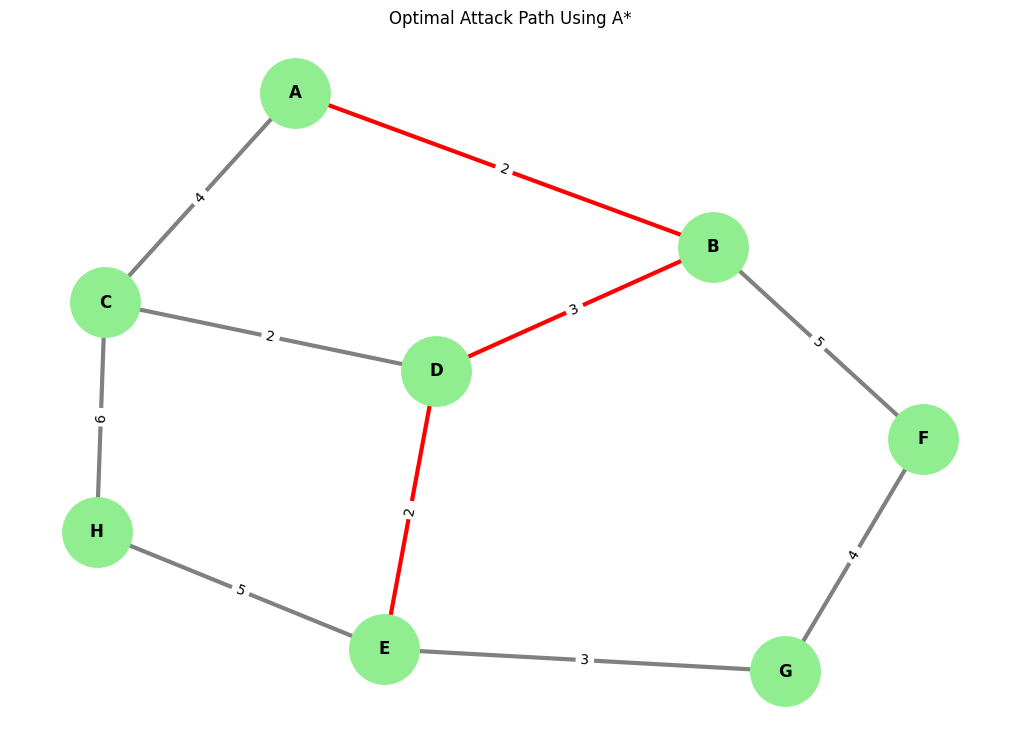

In [41]:
path_edges = list(zip(
    astar_result['Path'],
    astar_result['Path'][1:]
))

edge_colors = []

for edge in G.edges():

    if edge in path_edges or (edge[1], edge[0]) in path_edges:
        edge_colors.append('red')
    else:
        edge_colors.append('gray')

plt.figure(figsize=(10,7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightgreen',
    node_size=2500,
    edge_color=edge_colors,
    width=3,
    font_weight='bold'
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Optimal Attack Path Using A*")

plt.show()

# Conclusion

This project successfully implemented multiple AI search algorithms in a cybersecurity attack-path simulation environment.

The algorithms were compared using:
- Path cost
- Nodes expanded
- Execution time

A* and UCS produced optimal paths while Hill Climbing demonstrated limitations due to local maxima.